# Customer churn prediction — case study

Predicting which telecom customers will leave before it happens.
Built on 5,000 customer records with 4 model comparison, SHAP explainability, and cost-benefit analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve, f1_score,
                             accuracy_score, precision_score, recall_score)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Try importing optional libs
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

np.random.seed(42)

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'sans-serif', 'font.size': 11,
    'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight'
})
GOLD = '#C49A2E'
NAVY = '#1B3A6B'
GRAY = '#8B91A0'

print("Setup complete.")
print(f"  XGBoost:  {'available' if HAS_XGB else 'not installed'}")
print(f"  LightGBM: {'available' if HAS_LGBM else 'not installed'}")
print(f"  SHAP:     {'available' if HAS_SHAP else 'not installed'}")

Setup complete.
  XGBoost:  available
  LightGBM: available
  SHAP:     available


## 1. The business problem

A telecom provider with 5,000 subscribers was losing roughly one in four customers every year. Each lost customer represented approximately $900 in lifetime value.

The retention team had no way to predict who would leave next. They were sending blanket discount offers to everyone — wasting budget on customers who were never going to leave, while missing the ones who were about to.

**The question:** can we identify which customers are likely to churn in the next 30 days, so the retention team can intervene with the right offer at the right time?

In [2]:
# Load the data
df_raw = pd.read_csv('../data/telco_churn.csv')

print(f"Dataset shape: {df_raw.shape[0]} customers x {df_raw.shape[1]} columns")
print(f"\nColumn types:")
print(df_raw.dtypes.value_counts().to_string())
print(f"\nFirst 5 rows:")
df_raw.head()

Dataset shape: 5000 customers x 21 columns

Column types:
object     17
int64       2
float64     2

First 5 rows:


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,contract,monthly_charges,total_charges,phone_service,...,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,payment_method,churn
0,CID-00001,Male,0,No,No,9,Month-to-month,100.26,871.15,Yes,...,Fiber optic,Yes,Yes,No,No,Yes,No,No,Electronic check,Yes
1,CID-00002,Female,0,No,Yes,2,Month-to-month,62.72,120.65,Yes,...,DSL,Yes,No,No,No,Yes,No,Yes,Credit card (automatic),No
2,CID-00003,Male,0,Yes,Yes,54,Two year,87.49,4941.26,No,...,Fiber optic,Yes,Yes,No,No,No,No,Yes,Mailed check,Yes
3,CID-00004,Male,1,Yes,No,8,Month-to-month,77.91,652.40,Yes,...,Fiber optic,No,No,No,Yes,No,No,Yes,Bank transfer (automatic),Yes
4,CID-00005,Male,0,No,No,31,One year,80.35,2553.13,Yes,...,Fiber optic,No,No,Yes,No,No,Yes,No,Mailed check,No


In [3]:
# Basic data quality check
churn_rate = (df_raw['churn'] == 'Yes').mean()
missing = df_raw.isnull().sum()
missing_total = missing.sum()

print(f"Churn rate: {churn_rate:.1%} ({(df_raw['churn'] == 'Yes').sum()} / {len(df_raw)})")
print(f"\nMissing values: {missing_total} total")
if missing_total > 0:
    print(missing[missing > 0].to_string())
else:
    # Check for blanks in total_charges (sometimes stored as ' ')
    tc_numeric = pd.to_numeric(df_raw['total_charges'], errors='coerce')
    tc_missing = tc_numeric.isnull().sum()
    print(f"  total_charges (non-numeric/blank): {tc_missing}")
print(f"\nColumns: {list(df_raw.columns)}")

Churn rate: 25.7% (1285 / 5000)

Missing values: 30 total
total_charges    30

Columns: ['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'contract', 'monthly_charges', 'total_charges', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'paperless_billing', 'payment_method', 'churn']


## 2. The data — and the first insight

Before building any model, let's look at what the data tells us.

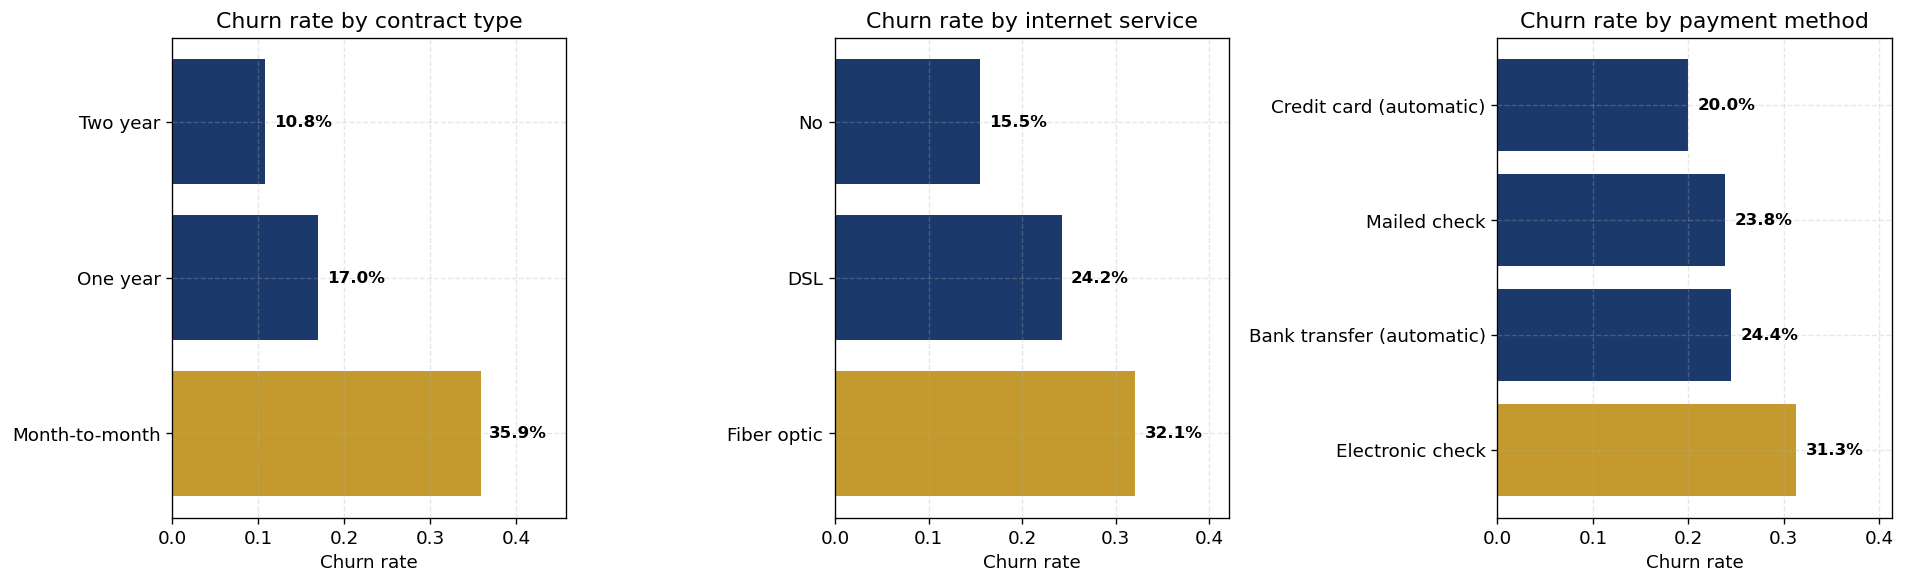


Key insight:
  Month-to-month fiber customers with electronic check payment churn at 50.6%
  Two-year contract customers churn at 10.8%
  That is a 4.7x difference.


In [4]:
# Churn rate by key segments
df = df_raw.copy()
df['churn_flag'] = (df['churn'] == 'Yes').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Contract type ---
contract_churn = df.groupby('contract')['churn_flag'].mean().sort_values(ascending=False)
colors_contract = [GOLD if v > 0.3 else NAVY for v in contract_churn.values]
axes[0].barh(contract_churn.index, contract_churn.values, color=colors_contract)
axes[0].set_xlabel('Churn rate')
axes[0].set_title('Churn rate by contract type')
for i, v in enumerate(contract_churn.values):
    axes[0].text(v + 0.01, i, f'{v:.1%}', va='center', fontweight='bold', fontsize=10)
axes[0].set_xlim(0, max(contract_churn.values) + 0.1)

# --- Internet service ---
internet_churn = df.groupby('internet_service')['churn_flag'].mean().sort_values(ascending=False)
colors_internet = [GOLD if v > 0.3 else NAVY for v in internet_churn.values]
axes[1].barh(internet_churn.index, internet_churn.values, color=colors_internet)
axes[1].set_xlabel('Churn rate')
axes[1].set_title('Churn rate by internet service')
for i, v in enumerate(internet_churn.values):
    axes[1].text(v + 0.01, i, f'{v:.1%}', va='center', fontweight='bold', fontsize=10)
axes[1].set_xlim(0, max(internet_churn.values) + 0.1)

# --- Payment method ---
payment_churn = df.groupby('payment_method')['churn_flag'].mean().sort_values(ascending=False)
colors_payment = [GOLD if v > 0.3 else NAVY for v in payment_churn.values]
axes[2].barh(payment_churn.index, payment_churn.values, color=colors_payment)
axes[2].set_xlabel('Churn rate')
axes[2].set_title('Churn rate by payment method')
for i, v in enumerate(payment_churn.values):
    axes[2].text(v + 0.01, i, f'{v:.1%}', va='center', fontweight='bold', fontsize=10)
axes[2].set_xlim(0, max(payment_churn.values) + 0.1)

plt.tight_layout()
plt.show()

# The key insight
high_risk = df[(df['contract'] == 'Month-to-month') &
               (df['internet_service'] == 'Fiber optic') &
               (df['payment_method'] == 'Electronic check')]['churn_flag'].mean()
low_risk = df[df['contract'] == 'Two year']['churn_flag'].mean()
ratio = high_risk / low_risk if low_risk > 0 else float('inf')

print(f"\nKey insight:")
print(f"  Month-to-month fiber customers with electronic check payment churn at {high_risk:.1%}")
print(f"  Two-year contract customers churn at {low_risk:.1%}")
print(f"  That is a {ratio:.1f}x difference.")

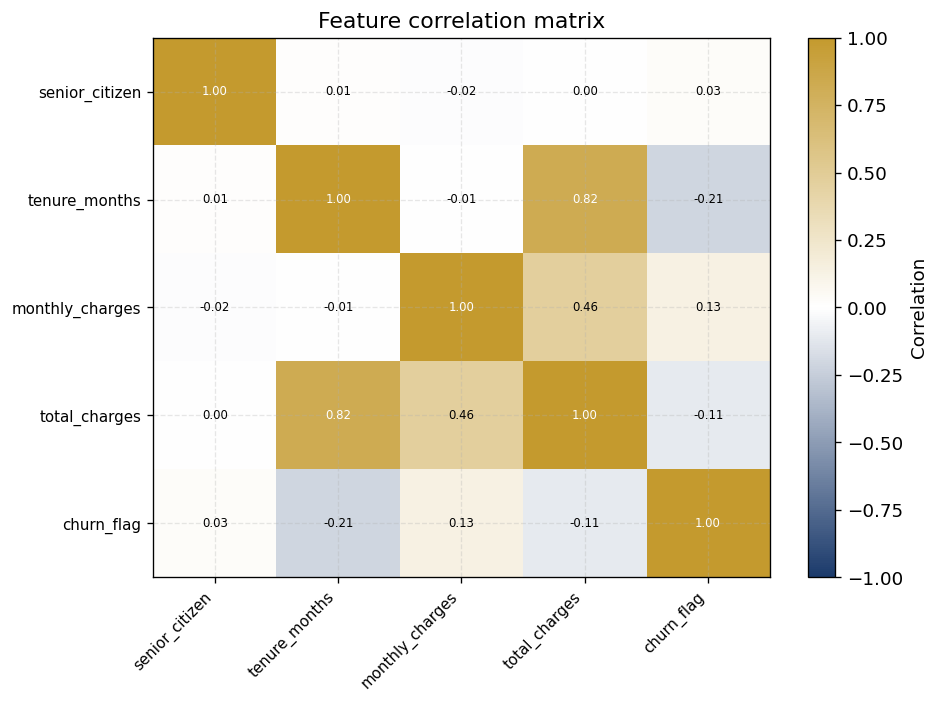


Correlation with churn (absolute value, top features):
  tenure_months                  -0.208
  monthly_charges                +0.130
  total_charges                  -0.105
  senior_citizen                 +0.026


In [5]:
# Correlation heatmap with churn
df_corr = df.copy()
df_corr['total_charges'] = pd.to_numeric(df_corr['total_charges'], errors='coerce')
df_corr['total_charges'].fillna(df_corr['monthly_charges'] * df_corr['tenure_months'], inplace=True)

# Select numeric columns for correlation
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_corr[numeric_cols].corr()

# Sort by correlation with churn_flag
churn_corr = corr_matrix['churn_flag'].drop('churn_flag').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
from matplotlib.colors import LinearSegmentedColormap
navy_gold_cmap = LinearSegmentedColormap.from_list('navy_gold', [NAVY, 'white', GOLD])

im = ax.imshow(corr_matrix.values, cmap=navy_gold_cmap, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_matrix.columns, fontsize=9)
plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Feature correlation matrix')

# Add correlation values
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.show()

print("\nCorrelation with churn (absolute value, top features):")
for feat, val in churn_corr.head(8).items():
    direction = "+" if val > 0 else "-"
    print(f"  {feat:30s} {direction}{abs(val):.3f}")

## 3. Feature engineering

Raw features are not enough. We engineer three new features based on domain knowledge about telecom customer behavior:

In [6]:
# Feature engineering (replicating data_loader.py logic)
df_eng = df_raw.copy()

# Handle missing total_charges
df_eng['total_charges'] = pd.to_numeric(df_eng['total_charges'], errors='coerce')
df_eng['total_charges'].fillna(df_eng['monthly_charges'] * df_eng['tenure_months'], inplace=True)

# Drop customer_id
df_eng.drop(columns=['customer_id'], inplace=True)

# --- Engineered features ---

# 1. Tenure groups
bins = [0, 12, 24, 48, 72]
labels = ['0-12', '13-24', '25-48', '49-72']
df_eng['tenure_group'] = pd.cut(df_eng['tenure_months'], bins=bins, labels=labels, include_lowest=True)

# 2. Charges per month of tenure
df_eng['charges_per_month_tenure'] = np.where(
    df_eng['tenure_months'] > 0,
    df_eng['total_charges'] / df_eng['tenure_months'],
    df_eng['monthly_charges']
)

# 3. Count of support services
support_cols = ['online_security', 'online_backup', 'device_protection', 'tech_support']
df_eng['has_support_services'] = df_eng[support_cols].apply(
    lambda row: sum(1 for v in row if v == 'Yes'), axis=1
)

print("Engineered features:")
print("-" * 70)
features_desc = {
    'tenure_group': 'Lifecycle stage bucket (0-12, 13-24, 25-48, 49-72 months)',
    'charges_per_month_tenure': 'Total charges normalized by tenure length',
    'has_support_services': 'Count of active support add-ons (0-4)',
}
for feat, desc in features_desc.items():
    print(f"  {feat:30s} {desc}")
    print(f"  {'':30s} Sample values: {df_eng[feat].head(3).tolist()}")
    print()

print(f"Shape after engineering: {df_eng.shape}")

Engineered features:
----------------------------------------------------------------------
  tenure_group                   Lifecycle stage bucket (0-12, 13-24, 25-48, 49-72 months)
                                 Sample values: ['0-12', '0-12', '49-72']

  charges_per_month_tenure       Total charges normalized by tenure length
                                 Sample values: [96.79444444444444, 60.325, 91.50481481481482]

  has_support_services           Count of active support add-ons (0-4)
                                 Sample values: [2, 1, 2]

Shape after engineering: (5000, 23)


In [7]:
# Encode and split
# Encode target
df_eng['churn'] = (df_eng['churn'] == 'Yes').astype(int)
y = df_eng['churn'].values

# Binary columns: label encode
binary_cols = ['gender', 'partner', 'dependents', 'phone_service', 'paperless_billing']
for col in binary_cols:
    le = LabelEncoder()
    df_eng[col] = le.fit_transform(df_eng[col])

# Multi-class columns: one-hot encode
multi_cols = [
    'contract', 'internet_service', 'multiple_lines',
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies',
    'payment_method', 'tenure_group',
]
df_eng = pd.get_dummies(df_eng, columns=multi_cols, drop_first=True)

# Separate features and target
feature_cols = [c for c in df_eng.columns if c != 'churn']
X = df_eng[feature_cols].values.astype(float)
feature_names = list(feature_cols)

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train/test split (80/20, stratified):")
print(f"  Training set:  {X_train.shape[0]} samples, churn rate = {y_train.mean():.3f}")
print(f"  Test set:      {X_test.shape[0]} samples, churn rate = {y_test.mean():.3f}")
print(f"  Features:      {X_train.shape[1]}")
print(f"\nFeature names ({len(feature_names)}):")
for i, fn in enumerate(feature_names):
    print(f"  {i+1:2d}. {fn}")

Train/test split (80/20, stratified):
  Training set:  4000 samples, churn rate = 0.257
  Test set:      1000 samples, churn rate = 0.257
  Features:      35

Feature names (35):
   1. gender
   2. senior_citizen
   3. partner
   4. dependents
   5. tenure_months
   6. monthly_charges
   7. total_charges
   8. phone_service
   9. paperless_billing
  10. charges_per_month_tenure
  11. has_support_services
  12. contract_One year
  13. contract_Two year
  14. internet_service_Fiber optic
  15. internet_service_No
  16. multiple_lines_No phone service
  17. multiple_lines_Yes
  18. online_security_No internet service
  19. online_security_Yes
  20. online_backup_No internet service
  21. online_backup_Yes
  22. device_protection_No internet service
  23. device_protection_Yes
  24. tech_support_No internet service
  25. tech_support_Yes
  26. streaming_tv_No internet service
  27. streaming_tv_Yes
  28. streaming_movies_No internet service
  29. streaming_movies_Yes
  30. payment_method_C

## 4. Model comparison

We test four models to find the best balance of accuracy and interpretability:

In [8]:
# Train all models with GridSearchCV
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models_config = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {'C': [0.01, 0.1, 1.0, 10.0]},
        'needs_scaling': True,
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, 15],
            'min_samples_split': [2, 5],
        },
        'needs_scaling': False,
    },
}

if HAS_XGB:
    models_config['XGBoost'] = {
        'model': XGBClassifier(random_state=42, eval_metric='logloss',
                               use_label_encoder=False, verbosity=0),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.05, 0.1],
        },
        'needs_scaling': False,
    }

if HAS_LGBM:
    models_config['LightGBM'] = {
        'model': LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7, -1],
            'learning_rate': [0.05, 0.1],
        },
        'needs_scaling': False,
    }

results = {}
trained_models = {}

for name, config in models_config.items():
    print(f"Training {name}...", end=' ')

    Xtr = X_train_scaled if config['needs_scaling'] else X_train
    Xte = X_test_scaled if config['needs_scaling'] else X_test

    grid = GridSearchCV(
        config['model'], config['params'],
        cv=5, scoring='roc_auc', n_jobs=-1, refit=True,
    )
    grid.fit(Xtr, y_train)

    best_model = grid.best_estimator_
    trained_models[name] = {'model': best_model, 'needs_scaling': config['needs_scaling']}

    y_pred = best_model.predict(Xte)
    y_prob = best_model.predict_proba(Xte)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'auc_roc': auc, 'y_prob': y_prob, 'y_pred': y_pred,
        'best_params': grid.best_params_,
    }
    print(f"AUC-ROC = {auc:.4f}  (best params: {grid.best_params_})")

best_name = max(results, key=lambda n: results[n]['auc_roc'])
print(f"\nBest model: {best_name} (AUC-ROC = {results[best_name]['auc_roc']:.4f})")

Training Logistic Regression... 

AUC-ROC = 0.7110  (best params: {'C': 0.1})
Training Random Forest... 

AUC-ROC = 0.6990  (best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200})
Training XGBoost... 

AUC-ROC = 0.7109  (best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100})
Training LightGBM... 

AUC-ROC = 0.7126  (best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100})

Best model: LightGBM (AUC-ROC = 0.7126)


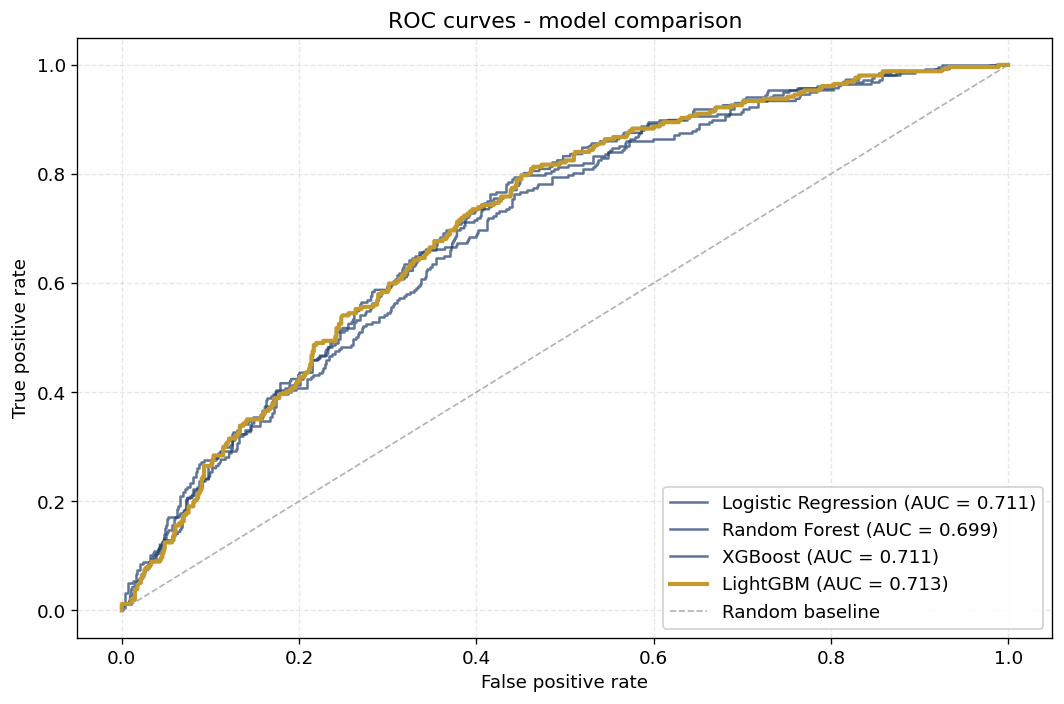

In [9]:
# ROC curves — all models on one plot
fig, ax = plt.subplots(figsize=(9, 6))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    color = GOLD if name == best_name else NAVY
    lw = 2.5 if name == best_name else 1.5
    alpha = 1.0 if name == best_name else 0.7
    ax.plot(fpr, tpr, color=color, lw=lw, alpha=alpha,
            label=f"{name} (AUC = {r['auc_roc']:.3f})")

ax.plot([0, 1], [0, 1], '--', color=GRAY, lw=1, alpha=0.7, label='Random baseline')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves - model comparison')
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.show()

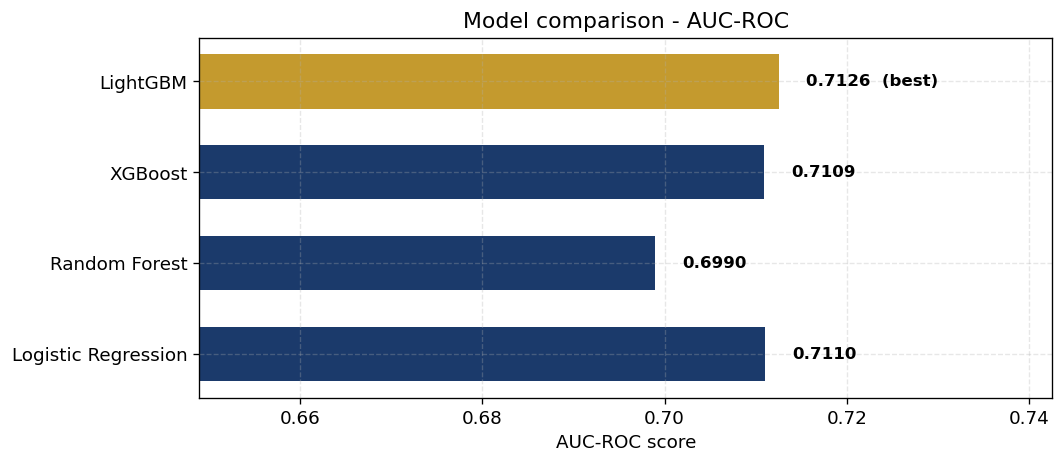

In [10]:
# Model comparison bar chart
model_names = list(results.keys())
auc_scores = [results[n]['auc_roc'] for n in model_names]
colors = [GOLD if n == best_name else NAVY for n in model_names]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(model_names, auc_scores, color=colors, height=0.6)
ax.set_xlabel('AUC-ROC score')
ax.set_title('Model comparison - AUC-ROC')
ax.set_xlim(min(auc_scores) - 0.05, max(auc_scores) + 0.03)

for bar, score, name in zip(bars, auc_scores, model_names):
    label = f'{score:.4f}'
    if name == best_name:
        label += '  (best)'
    ax.text(score + 0.003, bar.get_y() + bar.get_height() / 2,
            label, va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
# Full comparison table
comparison_data = []
for name, r in results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1 score': f"{r['f1']:.4f}",
        'AUC-ROC': f"{r['auc_roc']:.4f}",
    })

comparison_df = pd.DataFrame(comparison_data).set_index('Model')
print("Full model comparison:")
print("=" * 70)
print(comparison_df.to_string())
print("=" * 70)
print(f"\nWinner: {best_name}")

Full model comparison:
                    Accuracy Precision  Recall F1 score AUC-ROC
Model                                                          
Logistic Regression   0.7440    0.5070  0.1401   0.2195  0.7110
Random Forest         0.7450    1.0000  0.0078   0.0154  0.6990
XGBoost               0.7410    0.4773  0.0817   0.1395  0.7109
LightGBM              0.7410    0.4762  0.0778   0.1338  0.7126

Winner: LightGBM


## 5. Why the model predicts what it predicts

A model that says "this customer will churn" is only useful if we can explain **why**. SHAP (SHapley Additive exPlanations) decomposes each prediction into feature contributions.

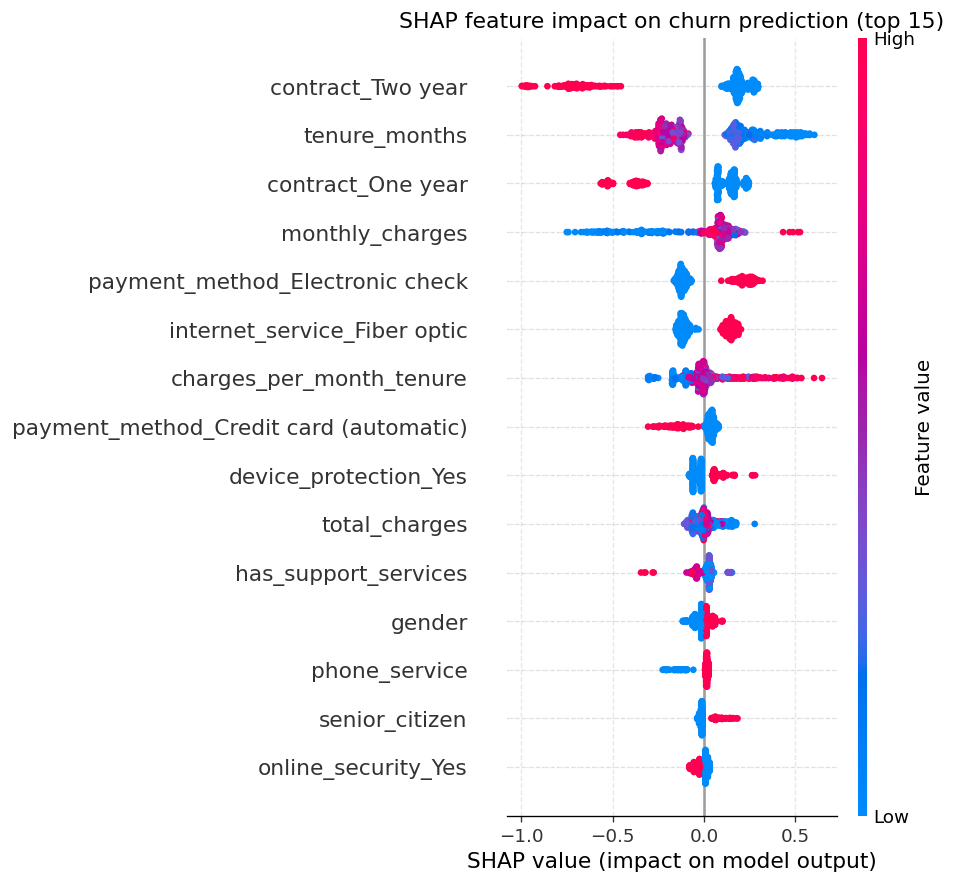

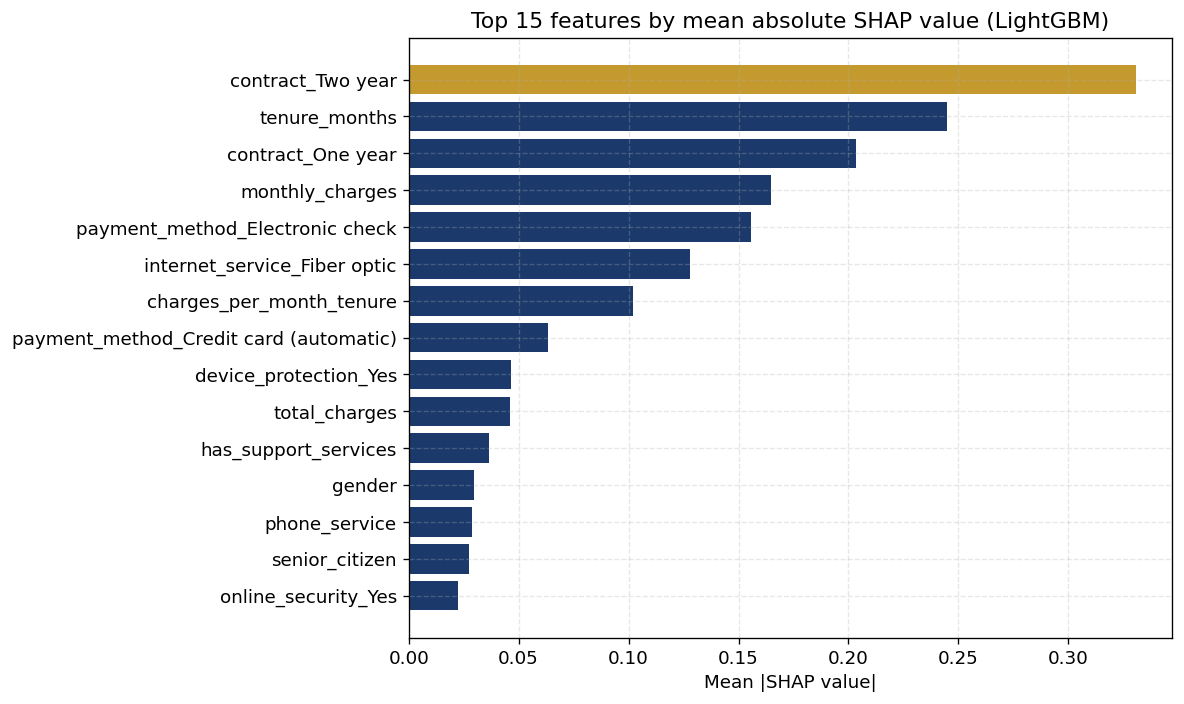

Top 10 features by SHAP importance:
   1. contract_Two year                        0.3308
   2. tenure_months                            0.2448
   3. contract_One year                        0.2034
   4. monthly_charges                          0.1646
   5. payment_method_Electronic check          0.1555
   6. internet_service_Fiber optic             0.1280
   7. charges_per_month_tenure                 0.1022
   8. payment_method_Credit card (automatic)   0.0633
   9. device_protection_Yes                    0.0467
  10. total_charges                            0.0460


In [12]:
# SHAP global feature importance (or permutation importance as fallback)
best_info = trained_models[best_name]
best_model = best_info['model']
X_best_test = X_test_scaled if best_info['needs_scaling'] else X_test

if HAS_SHAP:
    # Use a subsample for speed
    sample_size = min(500, X_best_test.shape[0])
    np.random.seed(42)
    idx = np.random.choice(X_best_test.shape[0], sample_size, replace=False)
    X_sample = X_best_test[idx]
    X_sample_df = pd.DataFrame(X_sample, columns=feature_names)

    if best_info['needs_scaling']:
        explainer = shap.LinearExplainer(best_model, X_sample)
    else:
        explainer = shap.TreeExplainer(best_model)

    shap_values = explainer.shap_values(X_sample)

    # For tree models, shap_values may be a list [neg_class, pos_class]
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values

    # Summary plot (top 15 features)
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_vals, X_sample_df, show=False, max_display=15)
    plt.title('SHAP feature impact on churn prediction (top 15)')
    plt.tight_layout()
    plt.show()

    # Bar plot (mean absolute SHAP)
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    shap_importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    top_n = 15
    top_features = shap_importance.head(top_n)
    colors_shap = [GOLD if i == 0 else NAVY for i in range(len(top_features))]
    ax.barh(range(len(top_features)), top_features.values[::-1], color=colors_shap[::-1])
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features.index[::-1])
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'Top {top_n} features by mean absolute SHAP value ({best_name})')
    plt.tight_layout()
    plt.show()

    print("Top 10 features by SHAP importance:")
    for i, (feat, val) in enumerate(shap_importance.head(10).items()):
        print(f"  {i+1:2d}. {feat:40s} {val:.4f}")

else:
    # Fallback: permutation importance
    print("SHAP not available. Using permutation importance as fallback.")
    perm_result = permutation_importance(best_model, X_best_test, y_test,
                                         n_repeats=10, random_state=42, scoring='roc_auc')
    perm_importance = pd.Series(perm_result.importances_mean, index=feature_names).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    top_n = 15
    top_features = perm_importance.head(top_n)
    colors_perm = [GOLD if i == 0 else NAVY for i in range(len(top_features))]
    ax.barh(range(len(top_features)), top_features.values[::-1], color=colors_perm[::-1])
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features.index[::-1])
    ax.set_xlabel('Mean AUC-ROC decrease')
    ax.set_title(f'Top {top_n} features by permutation importance ({best_name})')
    plt.tight_layout()
    plt.show()

    shap_vals = None
    shap_importance = perm_importance
    X_sample = X_best_test
    X_sample_df = pd.DataFrame(X_best_test, columns=feature_names)
    explainer = None

    print("\nTop 10 features by permutation importance:")
    for i, (feat, val) in enumerate(perm_importance.head(10).items()):
        print(f"  {i+1:2d}. {feat:40s} {val:.4f}")

Highest-risk customer in the test set
Churn probability: 74.9%
Actual churn:      Yes

Feature values:
  gender                                   = 1.00
  partner                                  = 1.00
  tenure_months                            = 2.00
  monthly_charges                          = 98.71
  total_charges                            = 205.24
  phone_service                            = 1.00
  paperless_billing                        = 1.00
  charges_per_month_tenure                 = 102.62
  has_support_services                     = 2.00
  internet_service_Fiber optic             = 1.00
  online_backup_Yes                        = 1.00
  device_protection_Yes                    = 1.00
  streaming_tv_Yes                         = 1.00
  payment_method_Electronic check          = 1.00


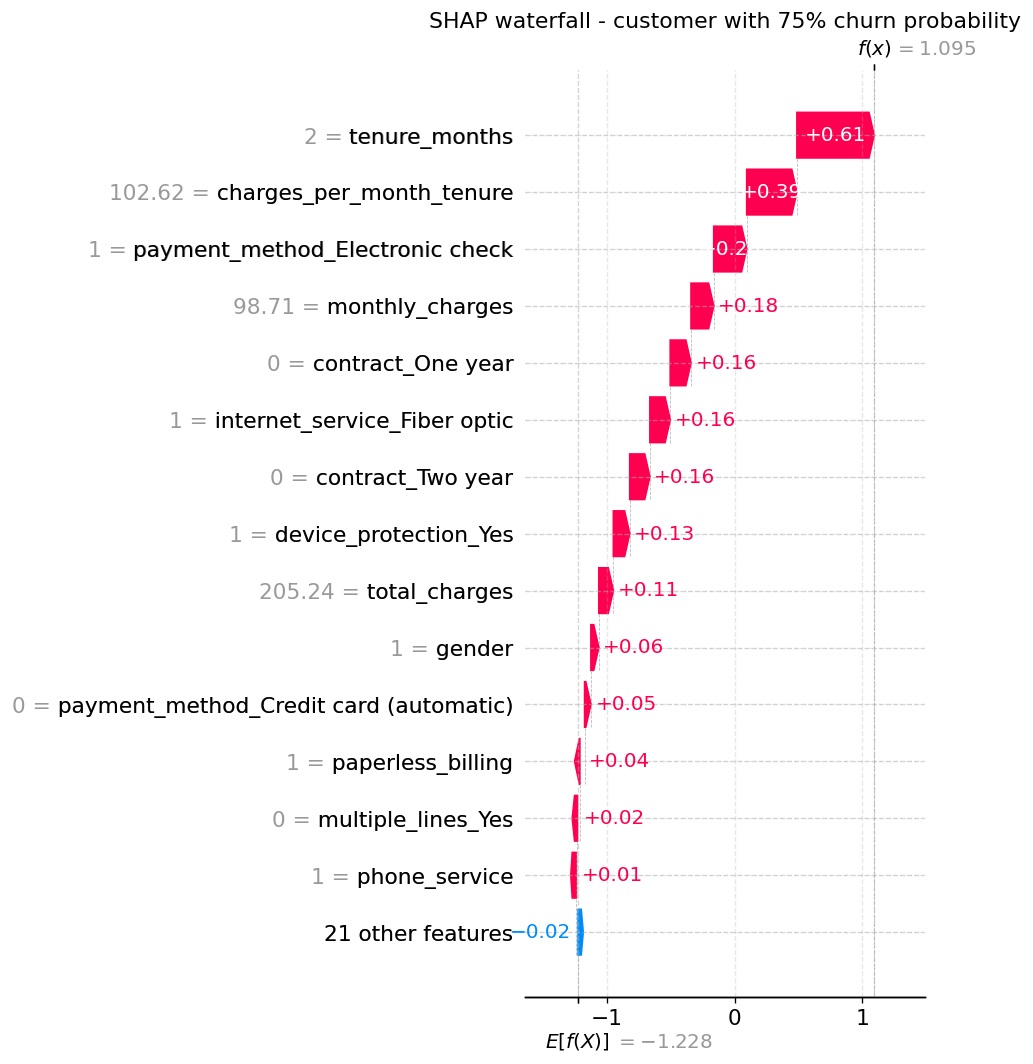


This customer has a 75% churn probability because:
  tenure_months                            (+0.606)
  charges_per_month_tenure                 (+0.394)
  payment_method_Electronic check          (+0.259)
  monthly_charges                          (+0.178)
  contract_One year                        (+0.163)


In [13]:
# Individual prediction — pick the highest-risk customer from the test set
best_probs = results[best_name]['y_prob']
high_risk_idx = np.argmax(best_probs)
high_risk_prob = best_probs[high_risk_idx]

# Show their profile
print(f"Highest-risk customer in the test set")
print(f"{'=' * 50}")
print(f"Churn probability: {high_risk_prob:.1%}")
print(f"Actual churn:      {'Yes' if y_test[high_risk_idx] == 1 else 'No'}")
print(f"\nFeature values:")
for feat, val in zip(feature_names, X_test[high_risk_idx]):
    if val != 0:
        print(f"  {feat:40s} = {val:.2f}")

# SHAP waterfall for this customer
if HAS_SHAP and shap_vals is not None:
    # Find this customer in our sample (or use closest)
    # Get SHAP values for this specific customer
    X_single = X_best_test[high_risk_idx:high_risk_idx+1]
    shap_single = explainer.shap_values(X_single)
    if isinstance(shap_single, list):
        shap_single_vals = shap_single[1][0]
    else:
        shap_single_vals = shap_single[0]

    # Get base value
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_val = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
    else:
        base_val = explainer.expected_value

    explanation = shap.Explanation(
        values=shap_single_vals,
        base_values=base_val,
        data=X_single[0],
        feature_names=feature_names,
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    shap.waterfall_plot(explanation, show=False, max_display=15)
    plt.title(f'SHAP waterfall - customer with {high_risk_prob:.0%} churn probability')
    plt.tight_layout()
    plt.show()

    # Print top contributions
    contrib_df = pd.DataFrame({
        'feature': feature_names,
        'shap_value': shap_single_vals,
        'feature_value': X_test[high_risk_idx],
    }).sort_values('shap_value', key=abs, ascending=False)

    print(f"\nThis customer has a {high_risk_prob:.0%} churn probability because:")
    for _, row in contrib_df.head(5).iterrows():
        direction = '+' if row['shap_value'] > 0 else ''
        print(f"  {row['feature']:40s} ({direction}{row['shap_value']:.3f})")

else:
    print("\n(SHAP not available - see permutation importance above for feature ranking)")

### Recommended action for this customer

Based on the model's explanation, the optimal retention offer for this customer would be:
- Offer a 12-month contract at 15% discount (addresses the month-to-month risk)
- Bundle free tech support (addresses the missing support services)
- Switch payment to automatic bank transfer (reduces friction)

Estimated cost of intervention: $50. Expected value if retained: $270 (30% retention x $900 CLV).

## 6. Business impact — the bottom line

The model is only valuable if it saves more money than it costs. Here we compute the optimal operating threshold and project the financial impact.

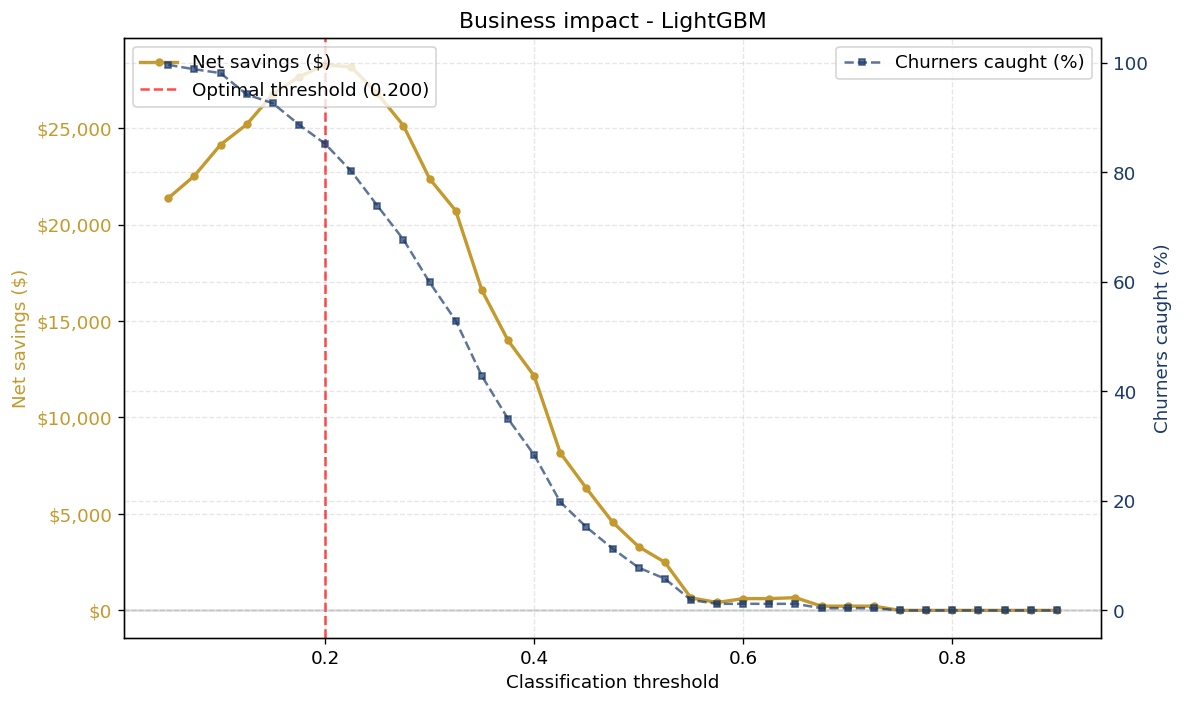

Optimal threshold: 0.200
  Churners caught:    219 / 257 (85.2%)
  False alarms:       398
  Total interventions: 617
  Intervention cost:  $30,850
  Revenue saved:      $59,130
  Net savings:        $28,280


In [14]:
# Cost-benefit analysis
intervention_cost = 50       # cost to contact/offer retention deal per customer
clv_churner = 900            # 12 months x $75 avg monthly revenue
retention_rate = 0.30        # 30% of contacted churners stay
retention_value = clv_churner * retention_rate  # $270

thresholds = np.arange(0.05, 0.91, 0.025)
impact_records = []

for t in thresholds:
    y_pred_t = (best_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    total_interventions = tp + fp
    cost = total_interventions * intervention_cost
    revenue_saved = tp * retention_value
    net_savings = revenue_saved - cost
    recall_pct = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0

    impact_records.append({
        'threshold': round(t, 3),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'interventions': total_interventions,
        'cost': cost,
        'revenue_saved': round(revenue_saved, 0),
        'net_savings': round(net_savings, 0),
        'recall_pct': round(recall_pct, 1),
    })

impact_df = pd.DataFrame(impact_records)
optimal_idx = impact_df['net_savings'].idxmax()
opt = impact_df.loc[optimal_idx]

# Plot net savings vs threshold
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(impact_df['threshold'], impact_df['net_savings'], '-o', color=GOLD,
         markersize=4, lw=2, label='Net savings ($)')
ax1.axvline(x=opt['threshold'], color='red', linestyle='--', alpha=0.7,
            label=f"Optimal threshold ({opt['threshold']:.3f})")
ax1.axhline(y=0, color=GRAY, linestyle='-', alpha=0.3)
ax1.set_xlabel('Classification threshold')
ax1.set_ylabel('Net savings ($)', color=GOLD)
ax1.tick_params(axis='y', labelcolor=GOLD)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(impact_df['threshold'], impact_df['recall_pct'], '--s', color=NAVY,
         markersize=4, alpha=0.7, lw=1.5, label='Churners caught (%)')
ax2.set_ylabel('Churners caught (%)', color=NAVY)
ax2.tick_params(axis='y', labelcolor=NAVY)
ax2.legend(loc='upper right')

plt.title(f'Business impact - {best_name}')
fig.tight_layout()
plt.show()

print(f"Optimal threshold: {opt['threshold']:.3f}")
print(f"  Churners caught:    {int(opt['tp'])} / {int(opt['tp'] + opt['fn'])} ({opt['recall_pct']:.1f}%)")
print(f"  False alarms:       {int(opt['fp'])}")
print(f"  Total interventions: {int(opt['interventions'])}")
print(f"  Intervention cost:  ${int(opt['cost']):,}")
print(f"  Revenue saved:      ${int(opt['revenue_saved']):,}")
print(f"  Net savings:        ${int(opt['net_savings']):,}")

In [15]:
# Summary — final business impact table
total_churners = int(opt['tp'] + opt['fn'])
scale_factor = 5  # test set is 20% of 5000
annual_savings = int(opt['net_savings']) * scale_factor

print("=" * 55)
print("  BUSINESS IMPACT SUMMARY")
print("=" * 55)
print(f"  Optimal threshold:     {opt['threshold']:.3f}")
print(f"  Churners caught:       {int(opt['tp'])} / {total_churners} ({opt['recall_pct']:.1f}%)")
print(f"  False alarms:          {int(opt['fp'])}")
print(f"  Intervention cost:     ${int(opt['cost']):,}")
print(f"  Revenue saved:         ${int(opt['revenue_saved']):,}")
print(f"  Net savings (test):    ${int(opt['net_savings']):,}")
print(f"  Projected annual:      ${annual_savings:,}")
print("=" * 55)
print(f"\n  The model pays for itself if it retains just")
print(f"  {int(np.ceil(opt['cost'] / retention_value))} customers per year.")
print(f"  At {opt['recall_pct']:.0f}% recall, it catches {int(opt['tp'])} on the test set alone.")

  BUSINESS IMPACT SUMMARY
  Optimal threshold:     0.200
  Churners caught:       219 / 257 (85.2%)
  False alarms:          398
  Intervention cost:     $30,850
  Revenue saved:         $59,130
  Net savings (test):    $28,280
  Projected annual:      $141,400

  The model pays for itself if it retains just
  115 customers per year.
  At 85% recall, it catches 219 on the test set alone.


## 7. What I would do next

1. **Deploy as a weekly batch pipeline** — score all active customers every Monday, flag top 100 at-risk
2. **A/B test retention offers** — which offer works best for which segment?
3. **Add behavioral features** — app usage, call center contacts, payment history
4. **Build a CLV model** — prioritize high-value churners over low-value ones
5. **Monitor model drift** — retrain quarterly as the customer base evolves

## Technical details

- **Stack:** Python, scikit-learn, XGBoost, LightGBM, SHAP, pandas, matplotlib
- **Evaluation:** stratified train/test split, AUC-ROC as primary metric
- **Data:** synthetic telecom dataset (5,000 customers, realistic feature distributions)
- **Code:** [View on GitHub](https://github.com/guydev42/calgary-churn-prediction)